### Домашнє завдання: Пониження розмірностей для Аналізу Портретів Клієнтів

#### Контекст
В цьому ДЗ ми попрацюємо з методами пониження розмірності на наборі даних для задачі аналізу портретів клієнтів (Customer Personality Analysis). **В попередньому ДЗ ми працювали з цими даними використовуючи кластеризацію, зараз використаємо кластеризацію і візуалізауємо результати з різними методами.**

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


Для початку, запустіть код нижче. Всі ці кроки ми робили в попередньому ДЗ і для того, щоб результати кластеризації у нас були схожими, потрібно аби передобробка була однаковою.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

# 1. Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/marketing_campaign.csv', delimiter='\t')

# 2. Обробка пропущених значень
df['Income_not_filled'] = df.Income.isna()
df.Income = df.Income.fillna(-1)

# 3. Обробка дати реєстрації
df.Dt_Customer = pd.to_datetime(df.Dt_Customer, format='%d-%m-%Y')
today = df.Dt_Customer.max()
df['days_lifetime'] = (today - df.Dt_Customer).dt.days
df['years_customer'] = df.Year_Birth.apply(lambda x: today.year - x)

# 4. Категоризація рівня освіти
df_education = pd.get_dummies(df.Education, prefix='education').astype(int)
df = pd.concat([df, df_education], axis=1)

# 5. Очищення сімейного стану
marital_status_map = {'Alone': 'Single', 'Absurd': 'Else', 'YOLO': 'Else'}
df['Marital_Status_clean'] = df.Marital_Status.map(marital_status_map)
df_ms = pd.get_dummies(df.Marital_Status_clean, prefix='marital').astype(int)
df = pd.concat([df, df_ms], axis=1)

# 6. Форматування доходу і видалення викиду
df.Income = df.Income.astype(int)
df = df[df.Income != 666666]

# 7. Створення фінального набору даних
X = df.drop(['ID', 'Dt_Customer', 'Education', 'Marital_Status', 'Marital_Status_clean'], axis=1)
X.reset_index(drop=True, inplace=True)

### Завдання 1: Виконання кластеризації та пониження розмірності для візуалізації результатів

Ваше завдання — провести кластеризацію клієнтів та візуалізувати результати кластеризації, використовуючи метод головних компонент (PCA) для пониження розмірності даних.

#### Інструкції:

1. **Вибір ключових характеристик:**
   Давайте обмежимось тільки наступними хараткеристиками для кластеризації цього разу:
   - `Income`: Річний дохід домогосподарства клієнта
   - `Recency`: Кількість днів з моменту останньої покупки клієнта
   - `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
   - `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
   - `days_lifetime`: Кількість днів з моменту реєстрації клієнта у компанії
   - `years_customer`: Вік клієнта
   - `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць
   Відберіть в наборі даних `X` лише ці характеристики.

2. **Стандартизація даних:**
   Використайте метод `StandardScaler` для стандартизації значень обраних характеристик.
   
   **Чому не MinMaxScaler:**
   - Для PCA краще використовувати StandardScaler, бо він вирівнює дисперсію ознак, на відміну від MinMaxScaler, що просто масштабує значення без врахування варіації.

   - Для K-Means також краще використовувати StandardScaler, бо алгоритм чутливий до масштабів: фічі з більшими значеннями сильніше впливають на обчислення відстаней, що може спотворити кластери.

3. **Кластеризація:**
   Проведіть кластеризацію клієнтів, використовуючи метод `KMeans` з трьома кластерами.

4. **Пониження розмірності:**
   Використайте метод головних компонент (PCA) для пониження розмірності даних до трьох компонент.

5. **Візуалізація результатів:**
   Використовуючи plolty express побудуйте 3D-графік розподілу клієнтів у просторі трьох головних компонент, де кольором позначено кластери.

6. **Опишіть, що спостерігаєте:**
   Чи кластеризація чітко розділила дані?

Далі ми детальніше проінтерпретуємо результати візуалізації і пониження розмірностей.

In [3]:
X_select = X[['Income', 'Recency', 'NumStorePurchases', 'NumDealsPurchases',
                'days_lifetime', 'years_customer', 'NumWebVisitsMonth']]

In [4]:
from sklearn.preprocessing import StandardScaler

def scale_data(df):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df)

    return pd.DataFrame(scaled, columns=df.columns, index=df.index)

In [5]:
X_select_scaled = scale_data(X_select)

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

def train_and_score(df):
    kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)
    labels = kmeans.fit_predict(df)

    silhouette_metric = silhouette_score(df, labels).round(3)
    print(f"Silhouette score: {silhouette_metric}")

    return labels

In [7]:
labels = train_and_score(X_select_scaled)
X_select_scaled['labels'] = labels

Silhouette score: 0.215


In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3, random_state=42)
pca_data = pca.fit_transform(X_select_scaled.drop(columns='labels'))

In [9]:
import plotly.express as px

# Create a DataFrame for Plotly Express
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2', 'PC3'], index=X_select_scaled.index)

pca_df['labels'] = X_select_scaled['labels']

# Create an interactive 3D scatter plot
fig = px.scatter_3d(
    pca_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='labels',
    title='3D PCA Visualization of Customer Clusters'
)

# Show the figure
fig.show()

**Висновки**

Після застосування PCA, на візуалізації видно, що кластери не мають чітких меж і частково перекриваються. Це підтверджується невисоким значенням метрики silhouette 0.215, що свідчить про помірну якість кластеризації

### Завдання 2: Аналіз результатів пониження розмірності

1. **Розрахунок частки поясненої дисперсії:**
   Визначте, яка частка загальної варіації даних пояснюється кожною з трьох головних компонент (PC1, PC2, PC3) за допомогою атрибуту `explained_variance_ratio_` об'єкта PCA. Виведіть результат на екран.

2. **Розрахунок кумулятивної частки поясненої дисперсії:**
   Обчисліть кумулятивну частку поясненої дисперсії для трьох головних компонент, щоб зрозуміти, скільки варіації даних пояснюється першими кількома компонентами.

In [10]:
print(pca.explained_variance_ratio_)

[0.31847333 0.19659128 0.1433869 ]


In [11]:
print((pca.explained_variance_ratio_).cumsum())

[0.31847333 0.51506461 0.6584515 ]


**Висновки**

Перші три головні компоненти пояснюють приблизно 66% загальної варіації даних, значна частина інформації зберігається після пониження розмірності, однак близько 34% варіації втрачається

Відсутність домінуючої компоненти свідчить про те, що дані мають складну структуру і не можуть бути добре описані лише одним або двома напрямками

### Завдання 3: Інтерпретація "Loadings"

Продовжуємо інтерпретацію результатів `PCA`і познайомимось з новим поняттям `loadings`, яке допоможе нам знайти звʼязок між головними компонентами і оригінальними ознаками в наборі даних.

Ми зараз побудували візуалізацію кластерів точок даних в просторі трьох головних компонент. Але хочеться знайти звʼязок між головними компонентами і оригінальними ознаками. Для розуміння, які початкові характеристики даних мають найбільший вплив на ці головні компоненти, ми можемо використати атрибут `components_` методу `PCA`.

#### Що таке `pca.components_`?

`pca.components_` — це масив, який містить коефіцієнти (або "ваги"), що показують внесок кожної вихідної ознаки у кожну з головних компонент. Ці коефіцієнти ще називаються **"loading"** або "навантаженнями" компонент.

- **Loadings** (`навантаження`) відображають важливість кожної змінної (ознаки) для відповідної головної компоненти. Вони показують, яким чином змінні поєднуються, щоб утворити нові, зменшені вимірювання.
- Якщо коефіцієнт має високе абсолютне значення (як позитивне, так і негативне), це вказує на те, що відповідна змінна сильно впливає на головну компоненту.

#### Саме завдання
Ваше завдання — обчислити "навантаження" для кожної з головних компонент і інтерпретувати результати.

1. **Обчислення loadings для компонент:**
   Використайте атрибут `components_` об'єкта PCA для створення DataFrame, який відображатиме внесок кожної вихідної ознаки в кожну головну компоненту.

2. **Інтерпретація результатів:**
   Виведіть значення "навантажень" і проаналізуйте, які ознаки найбільше впливають на кожну головну компоненту.

In [12]:
pd.DataFrame(pca.components_, columns=X_select.columns, index=['PC1', 'PC2', 'PC3'])



,Income,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer,NumWebVisitsMonth
PC1,0.584238,0.010075,0.488621,-0.198661,-0.132683,0.189393,-0.571728
PC2,0.165255,0.036810,0.384659,0.608119,0.602585,0.208946,0.216329
PC3,-0.044491,0.975799,-0.080566,-0.034808,-0.022223,0.193368,-0.015815


**Висновки**

- PC1 найбільше пов’язана з Income, NumStorePurchases та NumWebVisitsMonth, описує поведінку клієнтів з високим доходом, які віддають перевагу беспосереднім покупкам в магазині
 - PC2 визначається змінними NumDealsPurchases та days_lifetime, що вказує на лояльних клієнтів, якікористуються знижками
- PC3 майже повністю визначається змінною Recency, кількість днів з моменту останньої покупки клієнта

###Завдання 4
Давайте проаналізуємо "навантаження" (**loadings**) для трьох головних компонент після вилучення ознаки `Income`. Це допоможе нам зрозуміти, як змінилася важливість інших ознак для кожної головної компоненти, коли одна з ключових характеристик (`Income`) була вилучена.

#### Кроки для проведення аналізу і ваше завдання:

1. Видаліть ознаку `Income` з нашого набору даних `X` і повторно виконайте PCA (метод головних компонент) для отримання нових "навантажень".

2. Обчисліть нові "навантаження" для трьох головних компонент на наборі даних без `Income`

3. Проаналізуйте, які ознаки мають найбільший вплив на кожну головну компоненту після вилучення `Income`.

4. Перегляньте, наскільки кожна з головних компонент пояснює дисперсію в даних без ознаки `Income`.

In [13]:
X_without_income = X_select_scaled.drop(columns=['Income', 'labels'])

pca_without_income = PCA(n_components=3, random_state=42)
pca_data_without_income = pca_without_income.fit_transform(X_without_income)

In [14]:
print(pca_without_income.explained_variance_ratio_)

[0.27392228 0.21444861 0.16684415]


In [15]:
print((pca_without_income.explained_variance_ratio_).cumsum())

[0.27392228 0.48837089 0.65521505]


In [16]:
pd.DataFrame(pca_without_income.components_, columns=X_without_income.columns, index=['PC1', 'PC2', 'PC3'])

,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer,NumWebVisitsMonth
PC1,-0.014416,-0.381237,0.445591,0.383782,-0.177270,0.690787
PC2,0.074880,0.629202,0.461539,0.467914,0.393576,-0.107863
PC3,0.990219,-0.111063,-0.061793,0.006776,0.056285,0.009910


**Висновки**

- Цікаво, що частка поясненої дисперсії трьома головними компонентами залишилась майже незмінною 66%, що свідчить про те, що структура варіації даних не залежить від однієї ознаки

- PC1 найбільше визначається змінними NumWebVisitsMonth, NumDealsPurchases, days_lifetime та NumStorePurchases

- PC2 формується змінними NumStorePurchases, NumDealsPurchases, days_lifetime та years_customer

 - PC3 так само як і попереднього разу майже повністю визначається змінною Recency

### Завдання 5: Візуалізація кластеризації за допомогою t-SNE

Ваше завдання — використати метод t-SNE для візуалізації результатів кластеризації клієнтів у двовимірному просторі. Метод t-SNE допомагає знизити розмірність даних та зберегти локальні структури в даних, що робить його ефективним для візуалізації високорозмірних даних. Ми також зможемо порівняти результат цього методу з РСА.

1. Використайте метод t-SNE для зниження розмірності до 2х вимірів даних, які включають ознаки всі, що і в завданні 1, а також були відмасштабовані перед пониженням розмірностей.

2. Створіть новий DataFrame з координатами, отриманими після застосування t-SNE, та додайте до нього мітки кластерів.

3. Побудуйте інтерактивний 2D-графік розподілу клієнтів, де кольором буде позначено різні кластери і проаналізуйте графік з рекомендаціями нижче (можливо треба буде вивести додаткові візуалізації чи таблиці для інтерпретації, але треба прям зрозуміти, які ознаки формують який кластер і чим кластери відрізняються одне від одного).

  **Опишіть отримані кластери з точки зору ознак.**

4. Опишіть відмінність графіка tSNE від PCA.

#### ЯК можна інтерпретувати з t-SNE?

Хоча t-SNE не надає "компонентів" як РСА, він забезпечує низьковимірне представлення даних, яке можна візуально інтерпретувати:

- **Кластери:** t-SNE особливо добре показує кластери подібних точок. Якщо ви бачите чітко визначені кластери на графіку t-SNE, це свідчить про наявність груп схожих спостережень у ваших даних. Проаналізувати їх можемо, якщо додамо дані в `hover_data` або якщо якісь з даних виведемо як розмір чи форма точок на візуалізації. Також корисно може бути вивести середні значення ознак по кластерам.
- **Локальна структура:** Відносне розташування точок одного кластеру на графіку t-SNE може допомогти вам зрозуміти, які дані подібні між собою.
- **Глобальна структура:** Будьте обережні; t-SNE менш надійний для відображення глобальних структур (наприклад, відстаней між кластерами) у порівнянні з PCA, бо t-SNE націлений на збереження саме локальних структур.

In [18]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)

tsne_result = tsne.fit_transform(X_select_scaled.drop(columns='labels'))

tsne_data = pd.DataFrame(tsne_result, columns=['tsne1', 'tsne2'])
tsne_data['labels'] = X_select_scaled['labels']

In [19]:
tsne_data

,tsne1,tsne2,labels
0,-6.178016,17.960560,2
1,-2.020363,-32.055527,0
2,30.192947,-1.143682,1
3,-50.656998,-28.081440,0
4,-10.094508,36.594967,2
...,...,...,...
2234,0.098064,-1.715901,0
2235,-2.890427,34.549389,2
2236,25.603291,15.979753,1
2237,31.719282,-3.019279,1


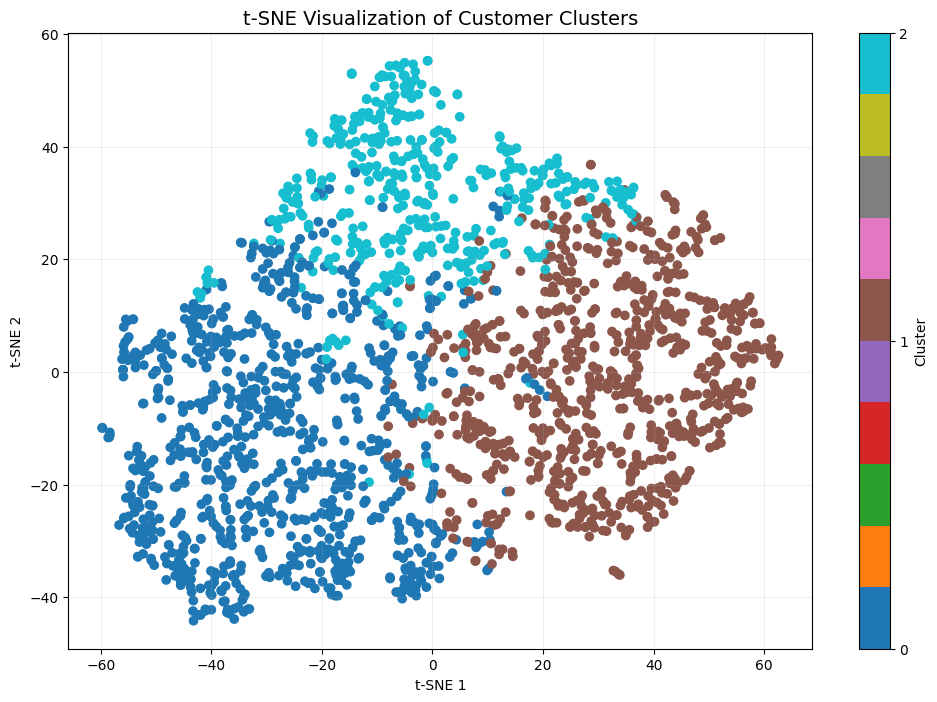

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

scatter = plt.scatter(tsne_data['tsne1'], tsne_data['tsne2'], c=tsne_data['labels'], cmap='tab10')

cbar = plt.colorbar(scatter, ticks=[0, 1, 2])
cbar.set_label('Cluster')

plt.title('t-SNE Visualization of Customer Clusters', fontsize=14)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

plt.grid(alpha=0.2)
plt.show()

In [21]:
import plotly.express as px

full_tsne_df = pd.concat([tsne_data, X_select], axis=1)

hover_columns = X_select.columns.tolist()

fig = px.scatter(full_tsne_df, x='tsne1', y='tsne2', color='labels', hover_data=hover_columns,
    title='2D t-SNE Visualization of Customer Clusters with Original Features')

fig.show()

In [26]:
full_tsne_df.drop(columns=(['tsne1', 'tsne2'])).groupby('labels').mean()

,Income,Recency,NumStorePurchases,NumDealsPurchases,days_lifetime,years_customer,NumWebVisitsMonth
labels,,,,,,,
0,33061.005203,48.509886,3.176899,1.811655,312.302810,41.919875,6.506764
1,72551.554070,49.345079,8.341434,1.442284,315.252734,47.347509,3.066829
2,51937.723077,50.006593,6.701099,5.002198,510.013187,48.232967,6.870330


**Висновки**

На основі середніх значень 3 сегменти виглядають
 - Кластер 0 клієнти з низьким рівнем доходу (Income 33061), невеликою кількістю покупок у магазині (NumStorePurchases 3.17)
 - Кластер 1 ці клієнти мають найвищий дохід (Income 72551), здійснюють найбільше покупок у магазинах (NumStorePurchases 8.34), рідше відвідують сайт (NumWebVisitsMonth 3.06) і майже не користуються знижками (NumDealsPurchases 1.44)
 - Кластер 2 клієнти з середнім дохдом (Income 51937), великою кількістю покупок зі знижками (NumDealsPurchases 5), довгим періодом взаємодії з компанією(days_lifetime	510) та високою онлайн-активністю (NumWebVisitsMonth 6.87)


PCA лінійний метод, який зберігає глобальну структуру даних і дозволяє інтерпретувати компоненти через навантаження ознак.

t-SNE нелінійний метод, який зберігає локальну структуру та краще підходить для візуалізації кластерів, але не дає прямої інтерпретації ознак


- На графіку t-SNE видно три відносно чіткі групи точок, що підтверджує наявність сегментів клієнтів.

 - Точки, розташовані близько одна до одної, мають подібні характеристики, що свідчить про внутрішню однорідність кластерів.

- Відстані між кластерами не слід інтерпретувати буквально, оскільки t-SNE може спотворювати глобальні взаємозв’язки між групами
